In [18]:
%matplotlib notebook
import numpy as np
from numpy import r_
import matplotlib.pyplot as mpl
import matplotlib
matplotlib.rc('font',size=18)
import scipy.linalg as la
import scipy.interpolate as sciint
import contextlib

@contextlib.contextmanager
def printoptions(*args, **kwargs):
    original = np.get_printoptions()
    np.set_printoptions(*args, **kwargs)
    yield 
    np.set_printoptions(**original)

In [19]:
# Put the project directory on the path to make sure we can import PyNitride
import sys, os
sys.path.append(os.path.abspath("../"))

In [3]:
from pynitride import ParamDB, Material
pmdb=ParamDB(units='neu')
to_units=pmdb.to_units
q,hbar,m_e,nm=pmdb.get_constants("e,hbar,m_e,nm")

In [4]:
GaN=Material("GaN")
AlN=Material("AlN")
a0=GaN['lattice.a']
c0=GaN['lattice.c']
a=AlN['lattice.a']
#C13oC33=GaN['stiffness.C13']/GaN['stiffness.C33']
C13oC33=108/374
st=(a-a0)/a0
sz=-2*C13oC33*st

In [5]:
mez=GaN['electron.mzs']
met=GaN['electron.mxys']

In [6]:
for var in "A1,A2,A3,A4,A5,A6,A7,D1,D2,D3,D4,D5,D6,a1,a2,DeltaCR,DeltaSO".split(','):
    globals()[var]=GaN['hole.kp.'+var]

In [7]:
# No spin orbit
DeltaSO=0

In [8]:
# ac is absolute movement of conduction band
# a1 is movement of cond relative to CH

acz=a1+D1
act=a2+D2


In [9]:
Delta1=DeltaCR
Delta2=DeltaSO/3
Delta3=DeltaSO/3
Delta=np.sqrt(2)*Delta3

In [10]:
def H66(k,e):
    kx,ky,kz=k
    exx,eyy,ezz=e
    
    #92 again
    Lambda=(A1*kz**2+A2*(kx**2+ky**2))+D1*ezz+D2*(exx+eyy)
    Theta=(A3*kz**2+A4*(kx**2+ky**2))+D3*ezz+D4*(exx+eyy)
    F=Delta1+Delta2+Lambda+Theta
    G=Delta1-Delta2+Lambda+Theta
    K=A5*(kx+1j*ky)**2
    H=(1j*A6*kz-A7)*(kx+1j*ky)
    I=(1j*A6*kz+A7)*(kx+1j*ky)
    
    hmat=np.matrix([
            [F,0, -H.conjugate(), 0, K.conjugate(), 0],
            [0, G, Delta, -H.conjugate(), 0, K.conjugate()],
            [-H, Delta, Lambda, 0, I.conjugate(), 0],
            [0, -H, 0, Lambda, Delta, I.conjugate()],
            [K, 0, I, Delta, G, 0],
            [0, K, 0, I, 0, F]])\
        -(Delta1+Delta2)*np.eye(6)
    return la.eigvalsh(hmat)

def Hcond(k,e):
    kx,ky,kz=k
    exx,eyy,ezz=e
    return np.array([hbar**2*(kx**2+ky**2)/(2*met)+hbar**2*kz**2/(2*mez)+acz*ezz+act*(exx+eyy)])

In [11]:
sz

0.013944994742958303

In [12]:
st

-0.024145500156788915

In [13]:
def generate_path(points,n):
    points=[np.array(p) for p in points]
    return np.vstack(
            [np.array([np.linspace(0,1,n-1,endpoint=False)]).T*(pf-ps)+ps
        for ps,pf in zip(points[:-1],points[1:])]+[points[-1]])

In [14]:
kvecs=generate_path([[0,0,0]],n=1)

In [15]:
kvecs

array([[0, 0, 0]])

In [16]:
vbs_relaxed=np.array([H66(kvec,[0,0,0]) for kvec in kvecs])
vbs_strain=np.array([H66(kvec,[st,st,sz]) for kvec in kvecs])
cbs_relaxed=np.array([Hcond(kvec,[0,0,0]) for kvec in kvecs])
cbs_strain=np.array([Hcond(kvec,[st,st,sz]) for kvec in kvecs])

#vbs_relaxed=vbs_relaxed
#vbs_strain=vbs_strain

In [17]:
vbs_relaxed

array([[-0.01, -0.01,  0.  ,  0.  ,  0.  ,  0.  ]])

Analytic

In [303]:
# How cond theoretically moves
(acz*sz+act*2*st)/q

0.20845184734288788

In [304]:
# How A theoretically moves
((D1+D3)*sz+(D2+D4)*(2*st))

0.04343607621788119

In [305]:
# How C theoretically moves
((D1)*sz)+((D2)*(2*st))

-0.2689059819600459

In [306]:
# How gap theoretically changes
(acz-D1-D3)*sz+(act-D2-D4)*2*st

0.16501577112500668

Diag

In [307]:
# How cond actually moves
cbs_strain[0]-cbs_relaxed[0]

array([ 0.20845185])

In [308]:
# How A actually moves
vbs_strain[0][5]-vbs_relaxed[0][5]

0.04343607621788121

In [309]:
# How C actually moves
vbs_strain[0][0]-vbs_relaxed[0][0]

-0.26890598196004589

In [310]:
# How the gap actually changes
cbs_strain[0]-vbs_strain[0][5]-(cbs_relaxed[0]-vbs_relaxed[0][5])

array([ 0.16501577])

In [285]:
3.44+0.1650157711250069

3.605015771125007

In [286]:
cbs_relaxed[0]

array([ 0.])

In [220]:
vbs_relaxed[0]

array([-0.01, -0.01,  0.  ,  0.  ,  0.  ,  0.  ])

In [221]:
cbs_relaxed[0]-vbs_relaxed[0][5]

array([ 0.])

In [222]:
# How cond-C actually moves
cbs_strain[0]-vbs_strain[0][0]-(cbs_relaxed[0]-vbs_relaxed[0][0])

array([ 0.46735783])

In [162]:
vbs_relaxed

array([[-0.01, -0.01,  0.  ,  0.  ,  0.  ,  0.  ]])

In [87]:
pa=np.pi/a

In [88]:
Delta

0.0

In [89]:
kmax=1.5/nm
kvecs=generate_path(points=[[0,0,kmax],[0,0,0],[kmax,0,0]],n=500)

In [90]:
kvecs[499]

array([ 0.,  0.,  0.])

In [91]:
vbs_relaxed=np.array([H66(kvec,[0,0,0]) for kvec in kvecs])
vbs_strain=np.array([H66(kvec,[st,st,sz]) for kvec in kvecs])
cbs_relaxed=np.array([Hcond(kvec,[0,0,0]) for kvec in kvecs])
cbs_strain=np.array([Hcond(kvec,[st,st,sz]) for kvec in kvecs])

vbs_relaxed=vbs_relaxed-np.max(vbs_relaxed)
vbs_strain=vbs_strain-np.max(vbs_relaxed)

<IPython.core.display.Javascript object>


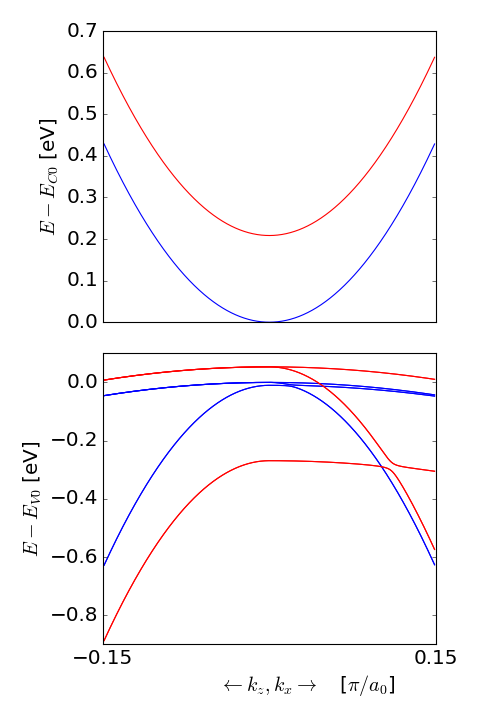

In [92]:
mpl.figure(figsize=(6,9))
mpl.subplot(212)
pseudo_k=np.array([la.norm(kvec)*(-1 if kvec[2]!=0 else 1) for kvec in kvecs])

mpl.plot(pseudo_k/pa,vbs_relaxed,'b',label='relaxed')
mpl.plot(pseudo_k/pa,vbs_strain,'r',label='strained')
mpl.ylim(-.05,.0)
mpl.ylim(-.9,.1)
mpl.xlim(-.15,.15)
mpl.xlabel('            $\\leftarrow k_z, k_x\\rightarrow$   [$\pi/a_0$]')
mpl.xticks([-.15,.15])
mpl.ylabel('$E-E_{V0}$ [eV]')
mpl.subplot(211)
mpl.plot(pseudo_k/pa,cbs_relaxed,'b')
mpl.plot(pseudo_k/pa,cbs_strain,'r')
mpl.xticks([])
mpl.ylabel('$E-E_{C0}$ [eV]')
mpl.xlim(-.15,.15)
#mpl.ylim(0,.05)
mpl.tight_layout()

In [292]:
-hbar**2/(2*m_e*(A1+A3))

1.8867924528301847

In [362]:
-hbar**2/(2*m_e*(A1+A3))

1.8867924528301847

In [363]:
-hbar**2/(2*m_e*(A1))

0.1386962552011096

In [364]:
-hbar**2/(2*m_e*(A2+A4-A5))

1.999999999999997

In [365]:
A7**2/Delta1

0.00877969

In [366]:
A2+A4-A5+A7**2/Delta1

-0.010270220137560189

In [367]:
-hbar**2/(2*m_e*((A2+A4-A5)+2*A7**2/abs(Delta1)))

25.561254559726613

In [368]:
-hbar**2/(2*m_e*(A2))+2*A7**2/abs(Delta1)

2.290286652727273

In [370]:
#unstrained
p=500-1
for i in reversed(2*np.arange(3)):
    print("E0={:.3g}".format(vbs_relaxed[499:][0,i]))
    print("mx={:.3g}".format(-1/(2*m_e/hbar**2*(vbs_relaxed[499:][p,i]-vbs_relaxed[499:][0,i])/kvecs[499:][p,0]**2)))
    print("mz={:.3g}".format(-1/(2*m_e/hbar**2*(vbs_relaxed[:500][500-p,i]-vbs_relaxed[:500][499,i])/kvecs[:500][500-p,2]**2)))
    print("\n")

E0=0
mx=1.92
mz=1.89


E0=-0.0052
mx=1.66
mz=1.67


E0=-0.0218
mx=0.14
mz=0.14




In [373]:
#strained
p=500-1
for i in reversed(2*np.arange(3)):
    print("E0={:.3g}".format(vbs_strain[499:][0,i]))
    print("mx={:.3g}".format(-1/(2*m_e/hbar**2*(vbs_strain[499:][p,i]-vbs_strain[499:][0,i])/kvecs[499:][p,0]**2)))
    print("mz={:.3g}".format(-1/(2*m_e/hbar**2*(vbs_strain[:500][500-p,i]-vbs_strain[500:][0,i])/kvecs[:500][500-p,2]**2)))
    print("\n")

E0=0.0591
mx=1.77
mz=1.89


E0=0.048
mx=0.242
mz=1.88


E0=-0.269
mx=0.28
mz=0.139




<IPython.core.display.Javascript object>


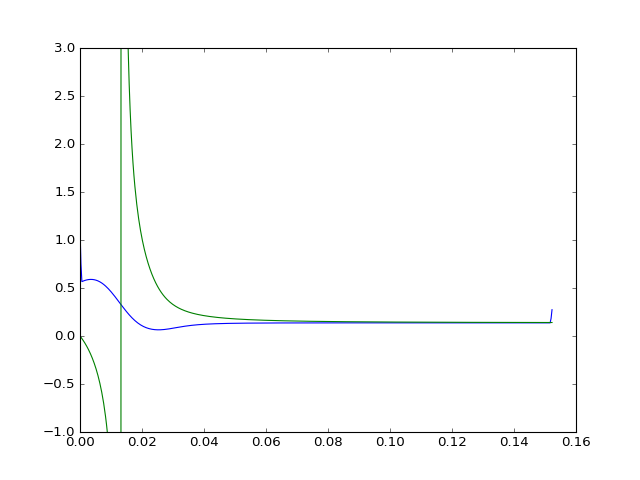

-c:5: RuntimeWarning: invalid value encountered in true_divide


(-1, 3)

In [242]:
i=1
whichbs=bskx
mpl.figure()
mpl.plot(k/pa,-hbar**2/np.gradient(np.gradient(q*(whichbs[:,i]-whichbs[0,i]),k[1]-k[0]),k[1]-k[0])/m0)
mpl.plot(k/pa,-hbar**2/(q*(whichbs[:,i]-whichbs[0,i])/k[:]**2)/(2*m0))
mpl.ylim(-1,3)

In [295]:
kvecs=generate_path([[-1.5e10,0,0],[1.5e10,0,0]],500)

In [319]:
cbs_strain_qw=np.array([Hcond(kvec,[st,st,sz]) for kvec in kvecs])
cbs_strain_qw-=np.min(cbs_strain)
cbs_strain_qw=cbs_strain_qw+np.array([0.75506612,   1.32832039])


<IPython.core.display.Javascript object>


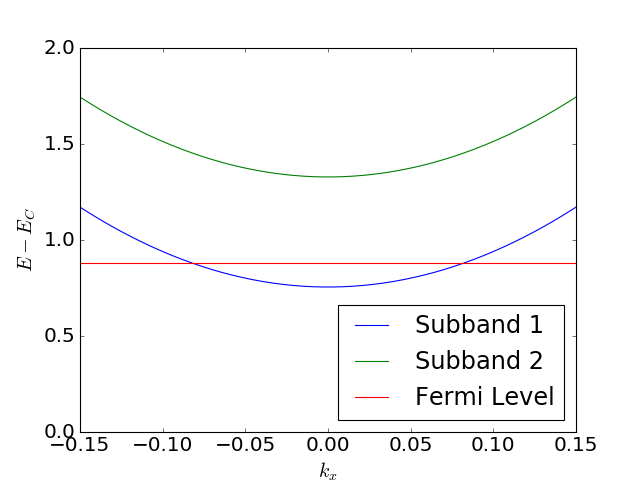

In [326]:
mpl.figure()
pseudo_k=np.array([kvec[0] for kvec in kvecs])
mpl.plot(pseudo_k/pa,cbs_strain_qw)
mpl.plot(pseudo_k/pa,.88+pseudo_k*0)
mpl.xlim(-.15,.15)
mpl.ylim(0,2)
mpl.xlabel('$k_x$')
mpl.ylabel('$E-E_{C}$')
mpl.legend(['Subband 1','Subband 2','Fermi Level'],loc='lower right')

In [301]:
cbs_strain

array([[ 0.63707483],
       [ 0.63535862],
       [ 0.63364586],
       [ 0.63193654],
       [ 0.63023066],
       [ 0.62852823],
       [ 0.62682923],
       [ 0.62513368],
       [ 0.62344158],
       [ 0.62175291],
       [ 0.62006769],
       [ 0.61838591],
       [ 0.61670758],
       [ 0.61503268],
       [ 0.61336123],
       [ 0.61169322],
       [ 0.61002866],
       [ 0.60836753],
       [ 0.60670986],
       [ 0.60505562],
       [ 0.60340482],
       [ 0.60175747],
       [ 0.60011356],
       [ 0.5984731 ],
       [ 0.59683607],
       [ 0.59520249],
       [ 0.59357236],
       [ 0.59194566],
       [ 0.59032241],
       [ 0.5887026 ],
       [ 0.58708623],
       [ 0.58547331],
       [ 0.58386383],
       [ 0.58225779],
       [ 0.58065519],
       [ 0.57905604],
       [ 0.57746033],
       [ 0.57586806],
       [ 0.57427923],
       [ 0.57269385],
       [ 0.57111191],
       [ 0.56953342],
       [ 0.56795836],
       [ 0.56638675],
       [ 0.56481858],
       [ 0